# Chapter 4 — Remaining Sections
## Geographic Data with Basemap + Visualization with Seaborn (Step-by-step Lecture Notebook)

**Based on Chapter 4, _Python Data Science Handbook_ by Jake VanderPlas.**

> This notebook covers the remaining sections commonly taught from Chapter 4:
> 1) Geographic data (Basemap)  
> 2) Visualization with Seaborn

### Learning goals
- Understand map projections and the Basemap workflow
- Plot points/paths on a map and format map features
- Use Seaborn for statistical visualizations: distributions, relationships, categories, and heatmaps
- Practice reproducible plotting with clean, readable figures

---

## Important note about Basemap
**Basemap is deprecated** (maintained but not actively developed). In modern Python geoviz, people often use **Cartopy** (maps) and **GeoPandas** (vector geodata).



In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(42)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)


NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0


# Part A — Geographic data with Basemap

Basemap provides map projections and helpers for:
- drawing coastlines/countries/states
- converting (lon, lat) → projected (x, y)
- plotting points/paths on a map

### Basemap workflow (mental model)
1. Create a `Basemap(...)` object with a projection and region
2. Draw base layers (coastlines, continents, boundaries)
3. Convert lon/lat to map coordinates using `m(lon, lat)`
4. Plot in map coordinates using Matplotlib


## A1) Install Basemap (Colab)
Basemap installation can be tricky.

### Option 1 (recommended for Colab)
Try installing `basemap` from pip:
```bash
!pip -q install basemap basemap-data-hires
```

### If Basemap fails
Skip to **A0-alt (Cartopy)** at the end of Part A.


In [66]:
# Colab install (uncomment if needed)
!pip -q install basemap basemap-data-hires


In [67]:
# Try importing Basemap
try:
    from mpl_toolkits.basemap import Basemap
    basemap_ok = True
    print("Basemap import: OK")
except Exception as e:
    basemap_ok = False
    print("Basemap import: FAILED")
    print("Error:", e)


Basemap import: OK


## A2) Your first map: World (cylindrical projection)
- `projection='cyl'` keeps lon/lat in a simple rectangular form.
- Good for learning; not best for accurate area/shape.


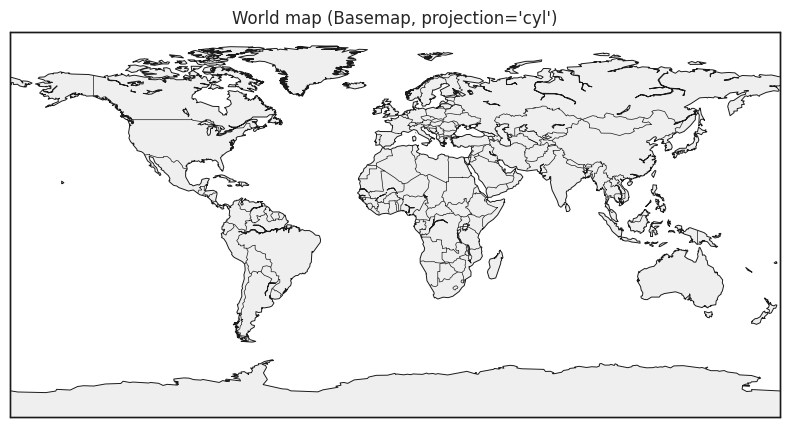

In [68]:
# Only run if basemap_ok == True
if basemap_ok:
    fig, ax = plt.subplots(figsize=(10, 5))
    m = Basemap(projection='cyl', resolution='c', ax=ax)  # 'c' = crude resolution (fast)

    m.drawcoastlines(linewidth=0.7)
    m.drawcountries(linewidth=0.5)
    m.fillcontinents(alpha=0.3)
    m.drawmapboundary()

    ax.set_title("World map (Basemap, projection='cyl')")
    plt.show()


## A3) Adding parallels/meridians (grid lines)
Parallels = latitude lines, Meridians = longitude lines.


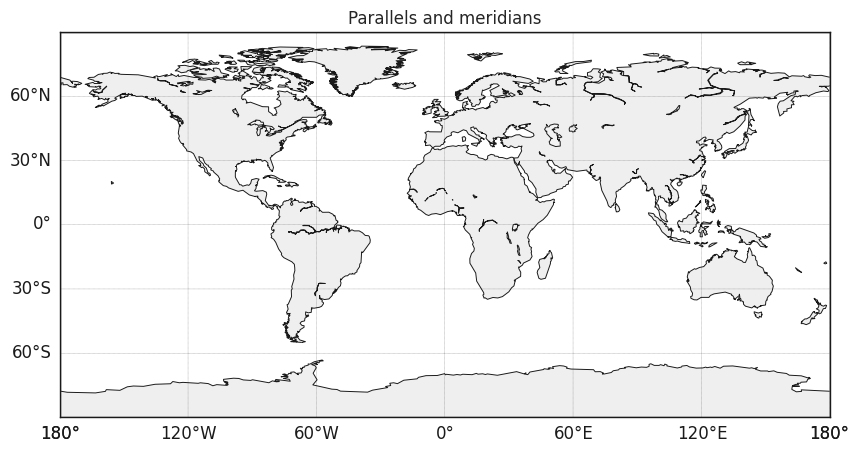

In [69]:
if basemap_ok:
    fig, ax = plt.subplots(figsize=(10, 5))
    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines(linewidth=0.7)
    m.fillcontinents(alpha=0.3)
    m.drawmapboundary()

    m.drawparallels(np.arange(-60, 90, 30), labels=[1,0,0,0], linewidth=0.2)
    m.drawmeridians(np.arange(-180, 181, 60), labels=[0,0,0,1], linewidth=0.2)

    ax.set_title("Parallels and meridians")
    plt.show()


## A4) Plotting points: Cities example
Steps:
1) Prepare lon/lat lists  
2) Convert via `x, y = m(lon, lat)`  
3) Plot with `m.scatter(...)` or `ax.scatter(...)`


In [99]:
# A few Southeast Asia cities (approximate coordinates)
cities = pd.DataFrame({
    "city": ["Bangkok", "Yangon", "Hanoi", "Manila", "Jakarta", "Singapore", "Mandalay", "NayPyiTaw", "Chiang Mai"],
    "lat":  [13.7563, 16.8409, 21.0278, 14.5995, -6.2088,  1.3521, 21.56190580, 19.745, 18.79038],
    "lon":  [100.5018, 96.1735, 105.8342, 120.9842, 106.8456, 103.8198, 95.89871390, 96.12972, 98.98468]
})
cities


,city,lat,lon
0,Bangkok,13.756300,100.501800
1,Yangon,16.840900,96.173500
2,Hanoi,21.027800,105.834200
3,Manila,14.599500,120.984200
4,Jakarta,-6.208800,106.845600
5,Singapore,1.352100,103.819800
6,Mandalay,21.561906,95.898714
7,NayPyiTaw,19.745000,96.129720
8,Chiang Mai,18.790380,98.984680


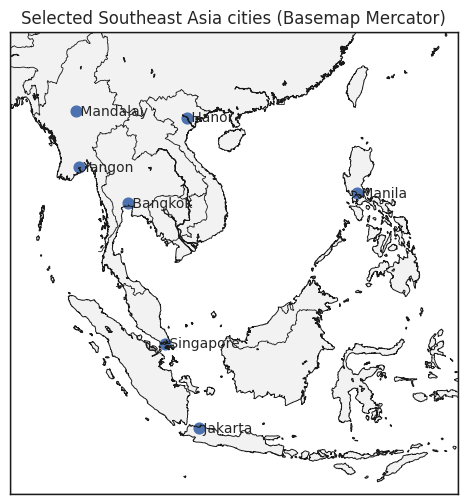

In [71]:
if basemap_ok:
    fig, ax = plt.subplots(figsize=(10, 6))
    m = Basemap(
        projection='merc',
        llcrnrlon=90, llcrnrlat=-12,
        urcrnrlon=130, urcrnrlat=28,
        resolution='i', ax=ax
    )
    m.drawcoastlines(linewidth=0.7)
    m.drawcountries(linewidth=0.6)
    m.fillcontinents(alpha=0.25)
    m.drawmapboundary()

    x, y = m(cities["lon"].to_numpy(), cities["lat"].to_numpy())

    m.scatter(x, y, s=60, marker="o")
    for xi, yi, name in zip(x, y, cities["city"]):
        ax.text(xi, yi, " " + name, fontsize=10, va="center")

    ax.set_title("Selected Southeast Asia cities (Basemap Mercator)")
    plt.show()




# The latitude of Mandalay Region, Myanmar is 21.56190580, and the longitude is 95.89871390.

In [72]:
#The latitude of Mandalay Region, Myanmar is 21.56190580, and the longitude is 95.89871390.

## A5) Great-circle lines (paths between points)
Use `m.drawgreatcircle(lon1, lat1, lon2, lat2, ...)`.


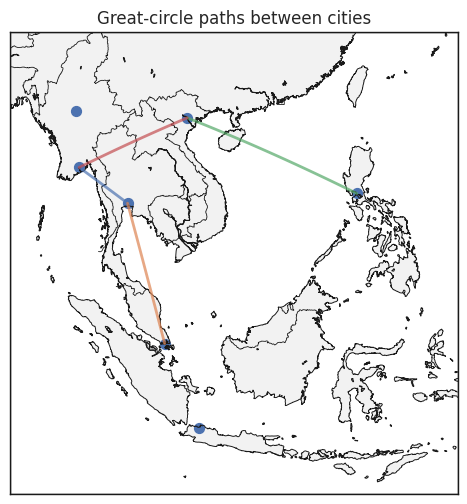

In [73]:
if basemap_ok:
    fig, ax = plt.subplots(figsize=(10, 6))
    m = Basemap(
        projection='merc',
        llcrnrlon=90, llcrnrlat=-12,
        urcrnrlon=130, urcrnrlat=28,
        resolution='i', ax=ax
    )
    m.drawcoastlines(linewidth=0.7)
    m.drawcountries(linewidth=0.6)
    m.fillcontinents(alpha=0.25)
    m.drawmapboundary()

    x, y = m(cities["lon"].to_numpy(), cities["lat"].to_numpy())
    m.scatter(x, y, s=50)

    def gc(a, b):
        m.drawgreatcircle(
            cities.loc[a, "lon"], cities.loc[a, "lat"],
            cities.loc[b, "lon"], cities.loc[b, "lat"],
            linewidth=2, alpha=0.7
        )

    gc(0, 1)  # Bangkok → Yangon
    gc(0, 5)  # Bangkok → Singapore
    gc(2, 3)  # Hanoi → Manila
    gc(1, 2)  # Yangon → Manila

    ax.set_title("Great-circle paths between cities")
    plt.show()


## A6) Map projections (quick comparison)
Try different projections:
- `cyl` (simple)
- `merc` (Mercator)
- `robin` (Robinson)
- `ortho` (Orthographic / globe-like)

Exercise: Run the cell and change `proj` to see the effect.


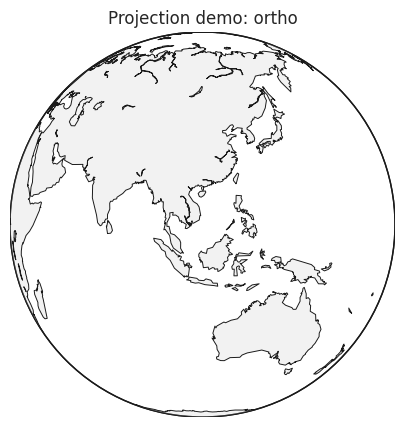

In [74]:
if basemap_ok:
    proj = "ortho"  # try: 'cyl', 'merc', 'robin', 'ortho'

    #ortho for sphere shpae world map (regular)
    #robin for


    fig, ax = plt.subplots(figsize=(10, 5))
    if proj == "ortho":
        m = Basemap(projection=proj, lat_0=10, lon_0=110, resolution='c', ax=ax)
    else:
        m = Basemap(projection=proj, lon_0=110, resolution='c', ax=ax)

    m.drawcoastlines(linewidth=0.7)
    m.fillcontinents(alpha=0.25)
    m.drawmapboundary()
    ax.set_title(f"Projection demo: {proj}")
    plt.show()


## A7) Mini Lab (Basemap)
### Task A
Create a Mercator map focusing on Thailand and nearby region. Add Bangkok (lat=13.7563, lon=100.5018) with a label.

### Task B
Add at least **3** cities of your choice and draw a great-circle line from Bangkok to each.

Write your solution in the cell below.


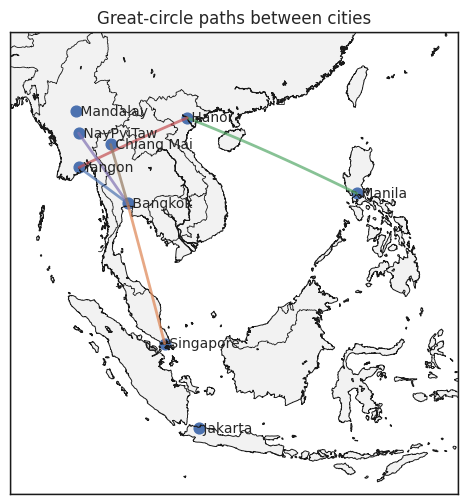

In [107]:
# Your Basemap mini-lab solution here

#Task A:

if basemap_ok:
    fig, ax = plt.subplots(figsize=(10, 6))
    m = Basemap(
        projection='merc',
        llcrnrlon=90, llcrnrlat=-12,
        urcrnrlon=130, urcrnrlat=28,
        resolution='i', ax=ax
    )
    m.drawcoastlines(linewidth=0.7)
    m.drawcountries(linewidth=0.6)
    m.fillcontinents(alpha=0.25)
    m.drawmapboundary()

    x, y = m(cities["lon"].to_numpy(), cities["lat"].to_numpy())

    m.scatter(x, y, s=60, marker="o")
    for xi, yi, name in zip(x, y, cities["city"]):
        ax.text(xi, yi, " " + name, fontsize=10, va="center")



    def gc(a, b):
        m.drawgreatcircle(
            cities.loc[a, "lon"], cities.loc[a, "lat"],
            cities.loc[b, "lon"], cities.loc[b, "lat"],
            linewidth=2, alpha=0.7
        )

    gc(0, 1)  # Bangkok → Yangon
    gc(0, 5)  # Bangkok → Singapore
    gc(2, 3)  # Hanoi → Manila
    gc(1, 2)  # Yangon → Manila
    gc(0, 7)  # Bangkok to NayPyiTaw
    gc(0, 8)  # Bangkok to Chiang Mai

    ax.set_title("Great-circle paths between cities")
    plt.show()




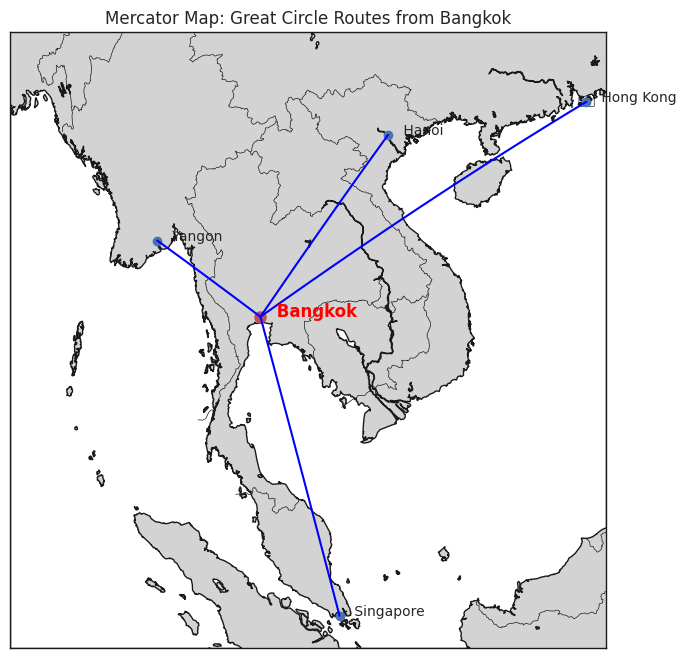

In [96]:
# Your Basemap mini-lab solution here

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# Task A: Create a Mercator map focusing on Thailand and nearby region
# Region defined by lower-left (ll) and upper-right (ur) coordinates
plt.figure(figsize=(10, 8))
m = Basemap(projection='merc',
            llcrnrlon=90, llcrnrlat=0,
            urcrnrlon=115, urcrnrlat=25,
            resolution='i')

# Draw map features
m.drawcoastlines()
m.drawcountries()
m.fillcontinents(color='lightgray', lake_color='white')
m.drawmapboundary(fill_color='white')

# Coordinates for Bangkok
bgk_lat, bgk_lon = 13.7563, 100.5018
x_bgk, y_bgk = m(bgk_lon, bgk_lat) # Convert lon/lat to map coordinates

# Add Bangkok marker and label
m.plot(x_bgk, y_bgk, 'ro', markersize=8) # Red dot for Bangkok
plt.text(x_bgk + 50000, y_bgk, ' Bangkok', fontsize=12, fontweight='bold', color='red')

# Task B: Add at least 3 cities and draw great-circle lines from Bangkok
cities = {
    'Singapore': (1.3521, 103.8198),
    'Hanoi': (21.0285, 105.8542),
    'Hong Kong': (22.3193, 114.1694),
    'Yangon': (16.8409, 96.1735)
}

for name, (lat, lon) in cities.items():
    # Convert city lon/lat to map coordinates for labeling
    cx, cy = m(lon, lat)

    # Plot the city marker and label
    m.plot(cx, cy, 'bo', markersize=6)
    plt.text(cx + 50000, cy, f' {name}', fontsize=10)

    # Draw great circle from Bangkok (lon1, lat1) to City (lon2, lat2)
    m.drawgreatcircle(bgk_lon, bgk_lat, lon, lat, linewidth=1.5, color='blue')

plt.title("Mercator Map: Great Circle Routes from Bangkok")
plt.show()


## A0-alt) If Basemap fails: a small Cartopy alternative (optional)
If Basemap doesn't install, Cartopy is a modern alternative, but it can also be heavy in Colab.

Try:
```bash
!pip -q install cartopy
```

Then run the code below.


In [76]:
# Optional install (uncomment if needed)
!pip -q install cartopy


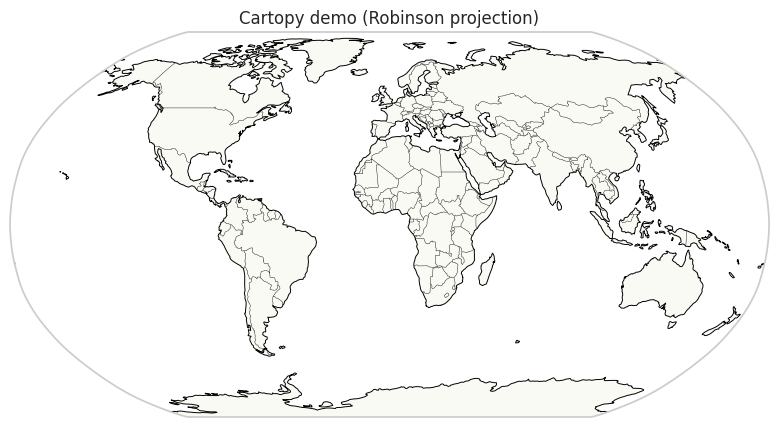

In [77]:
# Cartopy demo (only if you successfully installed cartopy)
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.Robinson())
    ax.set_global()
    ax.add_feature(cfeature.LAND, alpha=0.25)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_title("Cartopy demo (Robinson projection)")
    plt.show()
except Exception as e:
    print("Cartopy not available (this is okay):", e)


# Part B — Visualization with Seaborn
Seaborn builds on Matplotlib and makes **statistical visualization** easier.

### Seaborn strengths
- Nice default styles and color palettes
- Built-in datasets (`sns.load_dataset`)
- High-level plotting functions that work well with pandas

### Seaborn workflow (mental model)
1. Put data in a **pandas DataFrame**
2. Use `sns.<plot>(data=df, x=..., y=..., hue=...)`
3. Adjust labels and figure size when needed


## B1) Install and import Seaborn
In most environments, Seaborn is already installed.


In [78]:
import seaborn as sns

print("Seaborn:", sns.__version__)

# Set a default theme for seaborn figures
sns.set_theme()


Seaborn: 0.13.2


## B2) Built-in datasets
Seaborn includes small datasets for teaching.


In [79]:
# View available datasets (internet access may be required in some environments)
try:
    print(sns.get_dataset_names()[:10])
except Exception as e:
    print("Could not fetch dataset names:", e)


['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights']


In [80]:
# Load the classic 'tips' dataset
# (If this fails due to internet restrictions, use the fallback synthetic dataset below.)
try:
    tips = sns.load_dataset("tips")
    print("tips loaded:", tips.shape)
    display(tips.head())
except Exception as e:
    print("Could not load 'tips' dataset:", e)
    tips = pd.DataFrame({
        "total_bill": rng.normal(20, 8, 200).clip(5, 60),
        "tip": rng.normal(3, 1.2, 200).clip(0.5, 12),
        "sex": rng.choice(["Male", "Female"], 200),
        "smoker": rng.choice(["Yes", "No"], 200),
        "day": rng.choice(["Thur", "Fri", "Sat", "Sun"], 200),
        "time": rng.choice(["Lunch", "Dinner"], 200),
        "size": rng.integers(1, 6, 200),
    })
    display(tips.head())


tips loaded: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## B3) Relationship plots: scatter + regression
- `sns.scatterplot(...)`
- `sns.regplot(...)` adds a regression line
- `hue=` splits categories by color


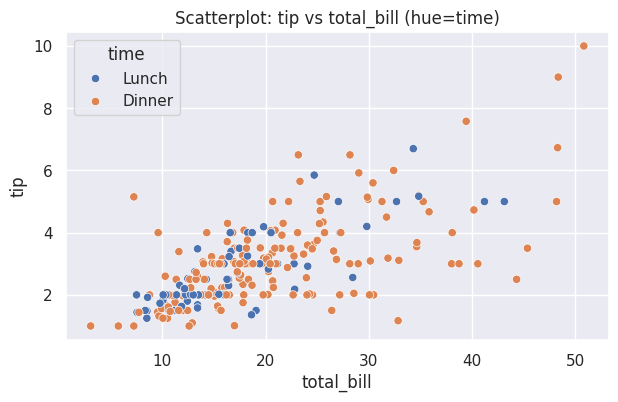

In [81]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time")
plt.title("Scatterplot: tip vs total_bill (hue=time)")
plt.show()


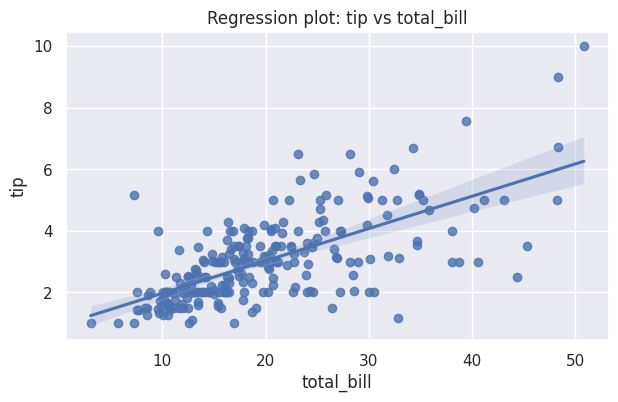

In [82]:
plt.figure(figsize=(7, 4))
sns.regplot(data=tips, x="total_bill", y="tip")
plt.title("Regression plot: tip vs total_bill")
plt.show()


## B4) Faceting: same plot split into multiple panels
Use `sns.relplot(...)` with `col=` / `row=`.


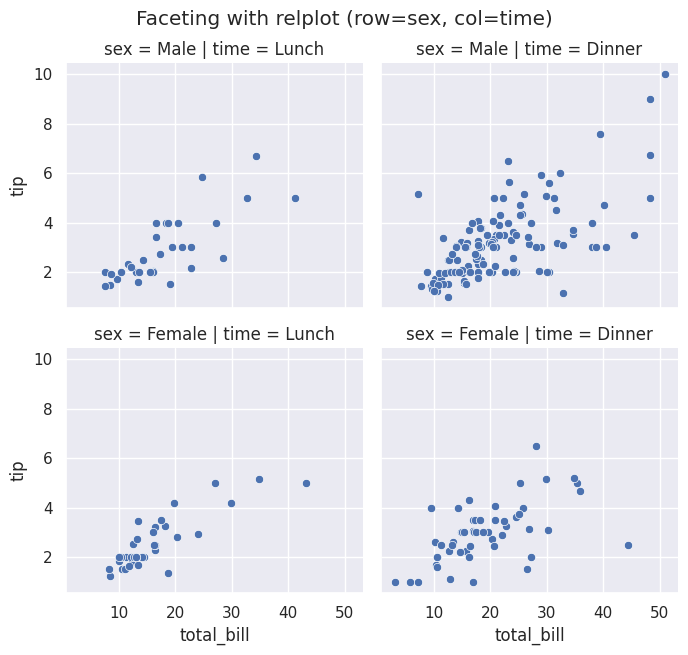

In [83]:
g = sns.relplot(
    data=tips,
    x="total_bill", y="tip",
    col="time", row="sex",
    kind="scatter",
    height=3.2, aspect=1.1
)
g.fig.suptitle("Faceting with relplot (row=sex, col=time)", y=1.02)
plt.show()


## B5) Distribution plots
- `sns.histplot(...)` for histogram
- `sns.kdeplot(...)` for density
- `sns.displot(...)` high-level distribution plot (faceting)


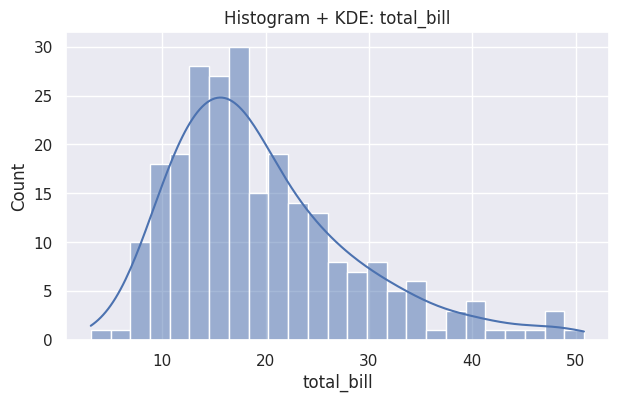

In [84]:
plt.figure(figsize=(7, 4))
sns.histplot(data=tips, x="total_bill", bins=25, kde=True)
plt.title("Histogram + KDE: total_bill")
plt.show()


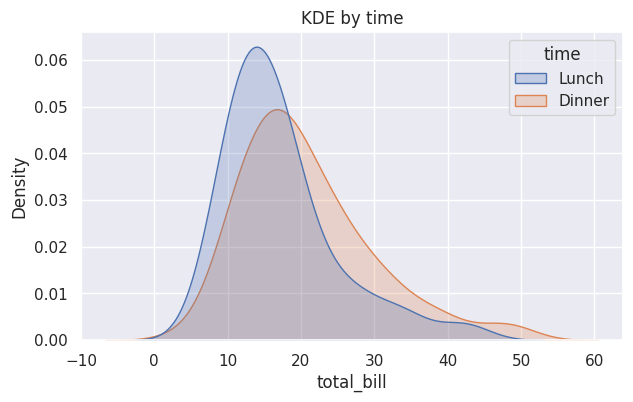

In [85]:
plt.figure(figsize=(7, 4))
sns.kdeplot(data=tips, x="total_bill", hue="time", fill=True, common_norm=False)
plt.title("KDE by time")
plt.show()


## B6) Categorical plots
Great for comparing groups:
- `sns.boxplot(...)`
- `sns.violinplot(...)`
- `sns.barplot(...)` (shows mean + confidence interval)


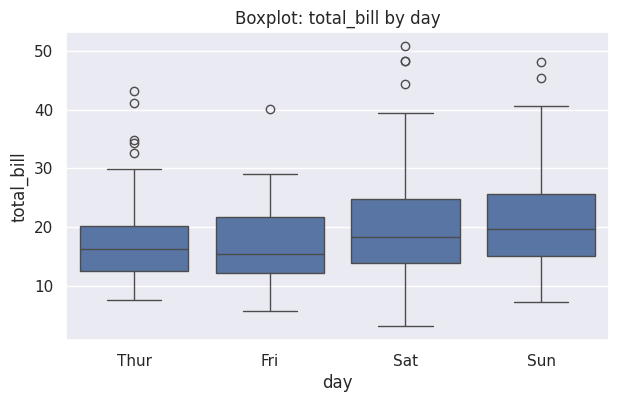

In [86]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Boxplot: total_bill by day")
plt.show()


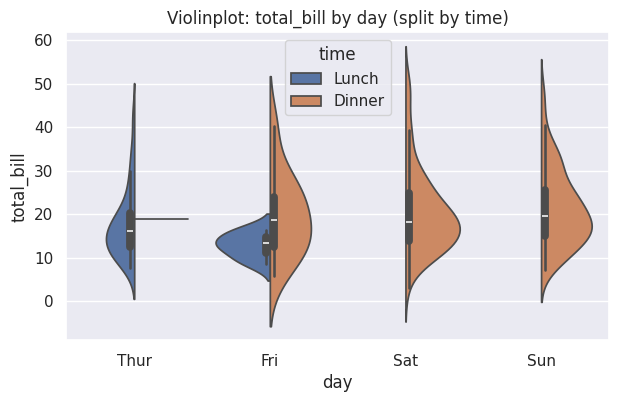

In [87]:
plt.figure(figsize=(7, 4))
sns.violinplot(data=tips, x="day", y="total_bill", hue="time", split=True)
plt.title("Violinplot: total_bill by day (split by time)")
plt.show()


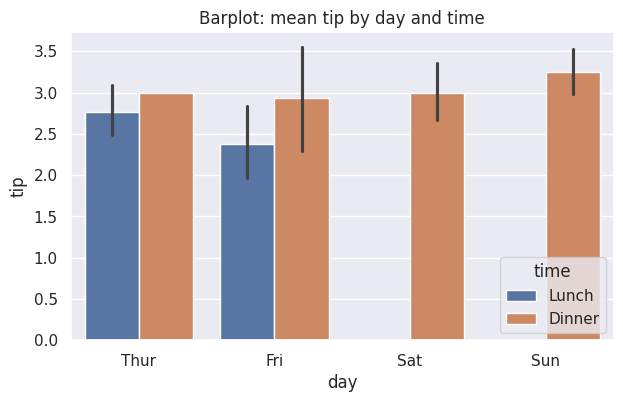

In [88]:
plt.figure(figsize=(7, 4))
sns.barplot(data=tips, x="day", y="tip", hue="time")
plt.title("Barplot: mean tip by day and time")
plt.show()


## B7) Pair plots (quick multivariate overview)
`sns.pairplot(...)` is helpful for small numeric datasets.


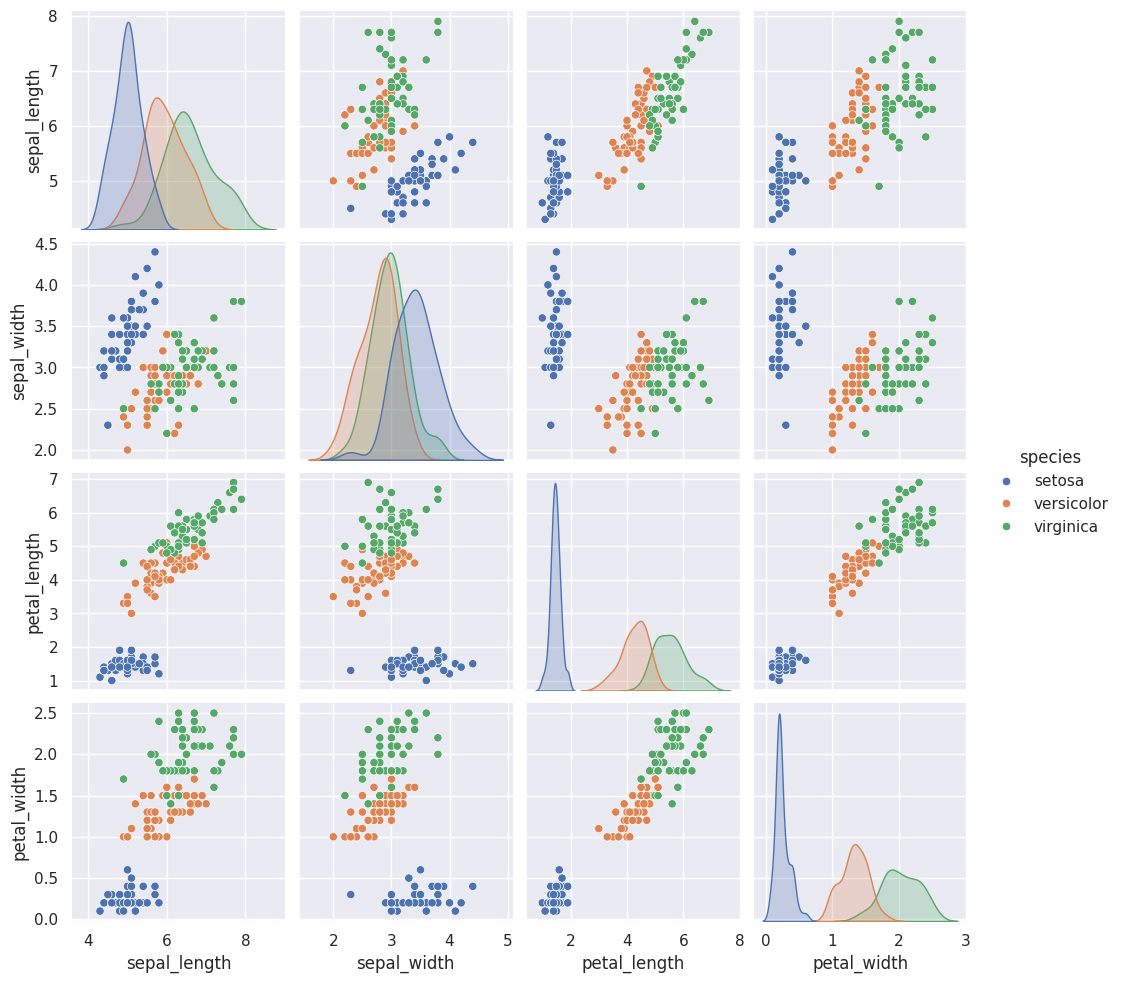

In [89]:
try:
    iris = sns.load_dataset("iris")
except Exception:
    iris = pd.DataFrame({
        "sepal_length": rng.normal(5.8, 0.8, 150),
        "sepal_width": rng.normal(3.0, 0.4, 150),
        "petal_length": rng.normal(3.7, 1.8, 150),
        "petal_width": rng.normal(1.2, 0.8, 150),
        "species": rng.choice(["setosa", "versicolor", "virginica"], 150)
    })

sns.pairplot(iris, hue="species")
plt.show()


## B8) Heatmaps
Heatmaps are great for correlation matrices and confusion matrices.


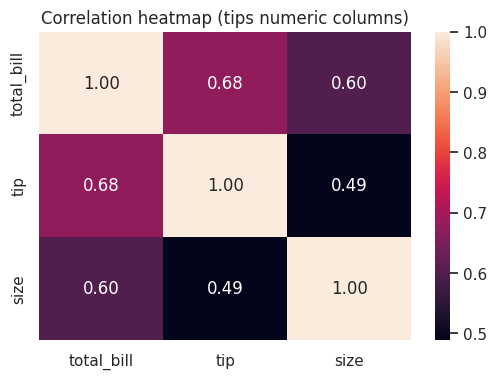

In [90]:
num_cols = tips.select_dtypes(include="number")
corr = num_cols.corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation heatmap (tips numeric columns)")
plt.show()


## B9) Styling and themes
Seaborn themes:
- `sns.set_theme(style='whitegrid')`

Palettes:
- `sns.color_palette('deep')`
- `sns.set_palette(...)`


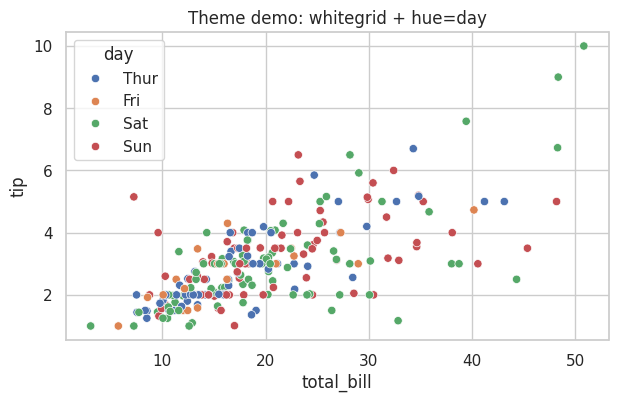

In [91]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(7, 4))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")
plt.title("Theme demo: whitegrid + hue=day")
plt.show()


## B10) Mini Lab (Seaborn)
### Task A — Relationship + Facet
Create a scatterplot of `total_bill` vs `tip` and facet by `time` (Lunch/Dinner).

### Task B — Distribution by group
Plot the distribution of `total_bill` separated by `sex` using either histplot or kdeplot.

### Task C — Heatmap
Create a correlation heatmap for the iris dataset numeric columns.

Write your solutions in the cells below.


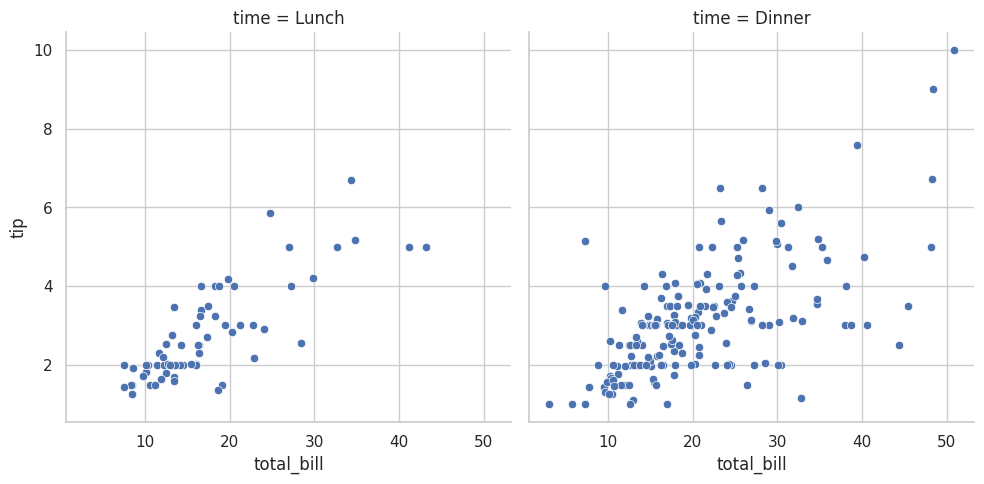

In [108]:
# Task A solution here
sns.relplot(data=tips, x='total_bill', y='tip', col='time', kind='scatter')
plt.show()

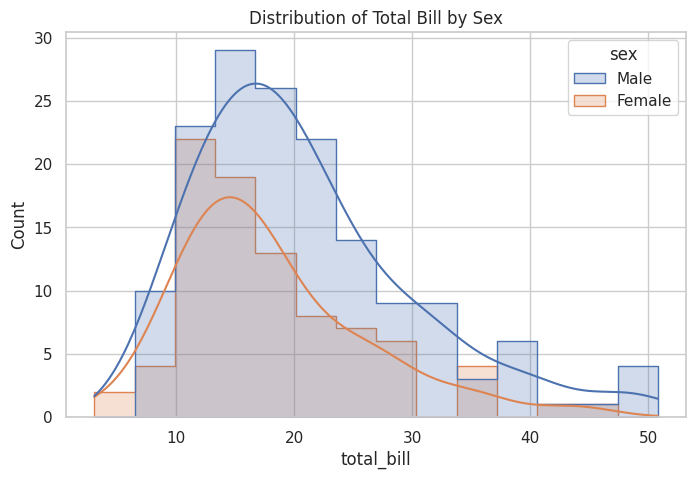

In [109]:
# Task B solution here
plt.figure(figsize=(8, 5))
sns.histplot(data=tips, x='total_bill', hue='sex', kde=True, element='step')
plt.title('Distribution of Total Bill by Sex')
plt.show()

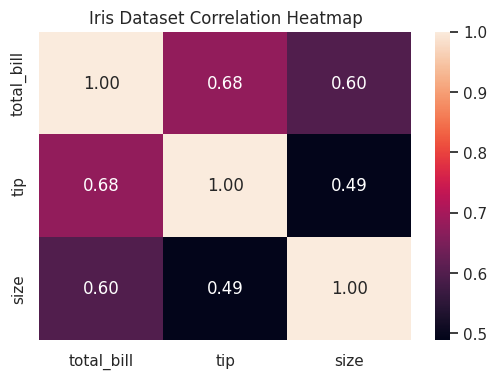

In [110]:
# Task C solution here
plt.figure(figsize=(6, 4))
iris_numeric = iris.select_dtypes(include="number")
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Iris Dataset Correlation Heatmap')
plt.show()

---
## Appendix: Quick Reference
### Basemap
- `m = Basemap(projection='merc', llcrnrlon=..., llcrnrlat=..., urcrnrlon=..., urcrnrlat=...)`
- `m.drawcoastlines(); m.drawcountries(); m.fillcontinents()`
- `x, y = m(lons, lats)`
- `m.scatter(x, y)`
- `m.drawgreatcircle(lon1, lat1, lon2, lat2)`

### Seaborn
- `sns.scatterplot(data=df, x=..., y=..., hue=...)`
- `sns.relplot(..., row=..., col=..., kind='scatter')`
- `sns.histplot(..., kde=True)` / `sns.kdeplot(..., fill=True)`
- `sns.boxplot(...)` / `sns.violinplot(...)` / `sns.barplot(...)`
- `sns.heatmap(corr, annot=True)`
